# 03 — Baseline Model (Pretrained MobileNetV3)
Donmuş backbone + fine-tune son katman. Scratch CNN için referans tavan.

In [1]:
import pickle
from pathlib import Path

# --- Yerel ---
CODE_ROOT = Path("../")
DATA_ROOT = Path("../")

# --- Colab ---
# from google.colab import drive
# drive.mount('/content/drive')
# CODE_ROOT = Path('/content/drive/MyDrive/film-genre-project')
# DATA_ROOT = Path('/content/drive/MyDrive/film-genre-project-data')
# import sys; sys.path.insert(0, str(CODE_ROOT / 'src'))

import sys
sys.path.insert(0, str(CODE_ROOT / "src"))

POSTERS_DIR = DATA_ROOT / "posters"
TRAIN_CSV   = DATA_ROOT / "train.csv"
VAL_CSV     = DATA_ROOT / "val.csv"
MLB_PKL     = DATA_ROOT / "mlb.pkl"
CKPT_DIR    = CODE_ROOT / "checkpoints" / "baseline"

with open(MLB_PKL, "rb") as f:
    mlb = pickle.load(f)

N_CLASSES = len(mlb.classes_)
print(f"N_CLASSES={N_CLASSES}  classes={mlb.classes_.tolist()}")

N_CLASSES=15  classes=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Thriller']


In [2]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

from dataset import PosterDataset
from transforms import train_transforms, val_transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 1. Dataset ve DataLoader

In [3]:
BATCH_SIZE = 64
NUM_WORKERS = 2

train_ds = PosterDataset(TRAIN_CSV, POSTERS_DIR, mlb, transform=train_transforms)
val_ds   = PosterDataset(VAL_CSV,   POSTERS_DIR, mlb, transform=val_transforms)

# WeightedRandomSampler — class imbalance
label_sums = train_ds.labels.sum(axis=0)
class_weights = 1.0 / (label_sums + 1e-6)
sample_weights = (train_ds.labels * class_weights).sum(axis=1)
sampler = WeightedRandomSampler(sample_weights.tolist(), len(sample_weights))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_ds):,}  Val: {len(val_ds):,}")

Train: 8,466  Val: 1,818


## 2. Model — MobileNetV3-Small (donmuş backbone)

In [4]:
weights = torchvision.models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
model = torchvision.models.mobilenet_v3_small(weights=weights)

# Backbone dondur
for param in model.parameters():
    param.requires_grad = False

# Son classifier katmanını değiştir
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, N_CLASSES)

model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\Kerem/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:02<00:00, 3.60MB/s]


Trainable params: 15,375 / 1,533,231


## 3. Eğitim

In [5]:
EPOCHS = 10
LR = 1e-3

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.classifier[-1].parameters(), lr=LR)

CKPT_DIR.mkdir(parents=True, exist_ok=True)

history = {"train_loss": [], "val_macro_f1": []}
best_f1 = 0.0


def eval_macro_f1(mdl, loader):
    mdl.eval()
    preds_all, targets_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            logits = mdl(imgs.to(DEVICE))
            preds_all.append((torch.sigmoid(logits) > 0.5).cpu().numpy())
            targets_all.append(labels.numpy())
    return f1_score(np.vstack(targets_all), np.vstack(preds_all),
                    average="macro", zero_division=0)


for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    val_f1 = eval_macro_f1(model, val_loader)
    avg_loss = total_loss / len(train_loader)
    history["train_loss"].append(avg_loss)
    history["val_macro_f1"].append(val_f1)
    print(f"Epoch {epoch:2d}/{EPOCHS}  loss={avg_loss:.4f}  val_macro_f1={val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), CKPT_DIR / "best.pt")

print(f"\nBest val Macro F1: {best_f1:.4f}")

Epoch  1/10  loss=0.4720  val_macro_f1=0.2330
Epoch  2/10  loss=0.4041  val_macro_f1=0.2752
Epoch  3/10  loss=0.3931  val_macro_f1=0.2905
Epoch  4/10  loss=0.3858  val_macro_f1=0.3014
Epoch  5/10  loss=0.3823  val_macro_f1=0.2997
Epoch  6/10  loss=0.3782  val_macro_f1=0.3035
Epoch  7/10  loss=0.3763  val_macro_f1=0.3062
Epoch  8/10  loss=0.3748  val_macro_f1=0.3149
Epoch  9/10  loss=0.3720  val_macro_f1=0.3127
Epoch 10/10  loss=0.3719  val_macro_f1=0.3206

Best val Macro F1: 0.3206


## 4. Eğitim eğrileri

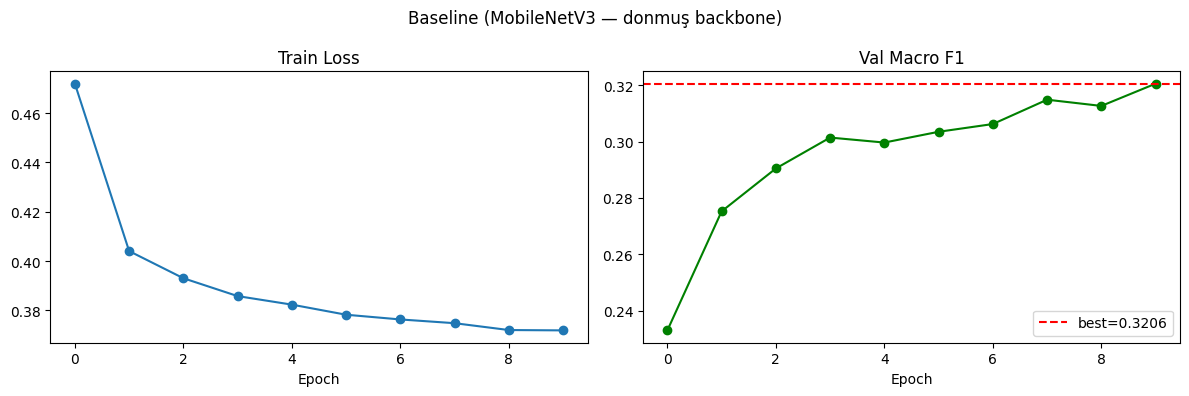

Baseline referans noktası: Macro F1 = 0.3206
Scratch CNN hedefi: bu değerin %60–70'i


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], marker="o")
ax1.set_title("Train Loss")
ax1.set_xlabel("Epoch")

ax2.plot(history["val_macro_f1"], marker="o", color="green")
ax2.set_title("Val Macro F1")
ax2.set_xlabel("Epoch")
ax2.axhline(best_f1, linestyle="--", color="red", label=f"best={best_f1:.4f}")
ax2.legend()

plt.suptitle("Baseline (MobileNetV3 — donmuş backbone)")
plt.tight_layout()
plt.show()

print(f"Baseline referans noktası: Macro F1 = {best_f1:.4f}")
print("Scratch CNN hedefi: bu değerin %60–70'i")